<a href="https://colab.research.google.com/github/kevinn78/salud_mental/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fase 1: Adquisición de Datos y Configuración del Entorno


En esta fase inicial, se establece la conexión con la fuente de datos y se configura el entorno de ejecución

In [14]:
# --- FASE 1: CARGA Y DIAGNÓSTICO REPRODUCIBLE ---
import pandas as pd
import os

# 1. CONFIGURACIÓN DE RUTA REPRODUCIBLE (Módulo 1.1)
if os.path.exists('data/raw/Dataset_salud_mental.zip'):
    path_raw = 'data/raw/'
    print("✅ Modo Local: Carpeta 'data' detectada en el repositorio.")
else:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    path_raw = '/content/drive/MyDrive/semestre 5/PROGRAMACION PARA LA CIENCIA DE DATOS/data/raw/'
    print("☁️ Modo Colab: Usando ruta de Google Drive.")

# 2. CARGA DEL DATASET
archivo_zip = os.path.join(path_raw, 'Dataset_salud_mental.zip')
df_mental = pd.read_csv(archivo_zip, compression='zip', encoding='latin-1')

# 3. REPORTE DE INCONSISTENCIAS (EVIDENCIA PARA LA DEFENSA)
print("\n" + "="*50)
print("🚨 REPORTE DE INCONSISTENCIAS GEOGRÁFICAS DETECTADAS:")
print(f"Total de registros cargados: {len(df_mental)}")
print(f"Nulos en la columna Country: {df_mental['Country'].isnull().sum()}")
print("="*50)

# Mostramos los primeros 20 registros para evidenciar nans y errores de código
display(df_mental[['Country', 'Country_Code']].head(20))


Mounted at /content/drive
☁️ Modo Colab: Usando ruta de Google Drive.

🚨 REPORTE DE INCONSISTENCIAS GEOGRÁFICAS DETECTADAS:
Total de registros cargados: 10000
Nulos en la columna Country: 2071


,Country,Country_Code
0,NaN,BR
1,Argentina,ES
2,BRASIL,CL
3,Peru,AR
4,Peru,PE
5,Chile,US
6,Spain,NaN
7,BRASIL,ES
8,NaN,BR
9,Argentina,??


Fase 2: Limpieza de Datos y Preprocesamiento Crítico

En esta etapa realizamos intervenciones manuales necesarias antes de automatizar el flujo con Pipelines. Estas acciones aseguran la calidad de la variable objetivo y la consistencia de las categorías.


In [15]:
# --- FASE 2:  ---
import numpy as np

print("🛠️ INICIANDO TRATAMIENTO ARTESANAL...\n")
df_clean = df_mental.copy()

# --- PASO 1: TRATAMIENTO DE NULOS (NaN) ---
df_clean.dropna(subset=['Country'], inplace=True)
print("1️⃣ [PASO NULOS]: Registros vacíos eliminados.")
display(df_clean[['Country', 'Country_Code']].head(5))

# --- PASO 2: MAPEO MANUAL (PAÍSES Y CÓDIGOS) ---
# Aquí corregimos Argentina, Perú, España y EE.UU. de forma manual
def mapeo_artesanal(row):
    pais = str(row['Country']).strip().upper()
    if 'ARGENT' in pais:
        row['Country'], row['Country_Code'] = 'Argentina', 'AR'
    elif 'PERU' in pais:
        row['Country'], row['Country_Code'] = 'Peru', 'PE'
    elif 'SPAIN' in pais or 'ESPA' in pais:
        row['Country'], row['Country_Code'] = 'España', 'ES'
    elif any(x in pais for x in ['USA', 'UNITED STATES', 'EEUU']):
        row['Country'], row['Country_Code'] = 'Estados Unidos', 'US'
    elif 'CHILE' in pais:
        row['Country'], row['Country_Code'] = 'Chile', 'CL'
    elif 'BRASIL' in pais or 'BRAZIL' in pais:
        row['Country'], row['Country_Code'] = 'Brasil', 'BR'
    else:
        row['Country'] = pais.title()
    return row

df_clean = df_clean.apply(mapeo_artesanal, axis=1)
print("\n2️⃣ [PASO MAPEO]: Nombres y códigos sincronizados manualmente.")
display(df_clean[['Country', 'Country_Code']].head(5))

# --- PASO 3: TRATAMIENTO DE DUPLICADOS ---
df_clean.drop_duplicates(inplace=True)
print("\n3️⃣ [PASO DUPLICADOS]: Filas repetidas eliminadas.")
display(df_clean[['Country', 'Country_Code']].head(5))

# --- PASO 4: CONTROL DE VALORES ATÍPICOS (OUTLIERS) ---
# Decidimos un rango de 2 a 14 horas.
# Mantenemos los extremos (2 y 14) porque en salud mental, dormir muy poco o demasiado
# son indicadores críticos de riesgo. Solo eliminamos lo biológicamente imposible.


df_clean['sleep_hours'] = np.clip(df_clean['sleep_hours'], a_min=2, a_max=14)
print("\n4️⃣ [PASO OUTLIERS]: Horas de sueño normalizadas (2-14 hrs).")
df_clean.reset_index(drop=True, inplace=True)
display(df_clean[['Country', 'Country_Code', 'sleep_hours']].head(5))


# --- PASO 5: FEATURE ENGINEERING (INGENIERÍA DE CARACTERÍSTICAS) ---
# Vamos a crear columnas nuevas que sean útiles para el análisis de salud mental.

# 1. Creamos una categoría de estrés (Bajo, Medio, Alto)
# Esto ayuda a simplificar el análisis numérico.
df_clean['stress_category'] = pd.cut(df_clean['stress_level'],
                                     bins=[0, 3, 7, 10],
                                     labels=['Bajo', 'Medio', 'Alto'])

# 2. Creamos un indicador de 'Sueño Insuficiente'
# Si duerme menos de 6 horas, marcamos un riesgo potencial (1=Sí, 0=No)
df_clean['insufficient_sleep'] = (df_clean['sleep_hours'] < 6).astype(int)

# 3. Columna combinada: Alerta de Salud Mental
# Si tiene estrés Alto Y sueño insuficiente, es una alerta crítica.
df_clean['mental_health_alert'] = ((df_clean['stress_category'] == 'Alto') &
                                   (df_clean['insufficient_sleep'] == 1)).astype(int)

print("✅ 5️⃣ [FEATURE ENGINEERING]: Se generaron 3 nuevas columnas: stress_category, insufficient_sleep y mental_health_alert.")
display(df_clean[['Country', 'stress_level', 'stress_category', 'mental_health_alert']].head(10))

🛠️ INICIANDO TRATAMIENTO ARTESANAL...

1️⃣ [PASO NULOS]: Registros vacíos eliminados.


,Country,Country_Code
1,Argentina,ES
2,BRASIL,CL
3,Peru,AR
4,Peru,PE
5,Chile,US



2️⃣ [PASO MAPEO]: Nombres y códigos sincronizados manualmente.


,Country,Country_Code
1,Argentina,AR
2,Brasil,BR
3,Peru,PE
4,Peru,PE
5,Chile,CL



3️⃣ [PASO DUPLICADOS]: Filas repetidas eliminadas.


,Country,Country_Code
1,Argentina,AR
2,Brasil,BR
3,Peru,PE
4,Peru,PE
5,Chile,CL



4️⃣ [PASO OUTLIERS]: Horas de sueño normalizadas (2-14 hrs).


,Country,Country_Code,sleep_hours
0,Argentina,AR,6.2
1,Brasil,BR,5.3
2,Peru,PE,7.1
3,Peru,PE,5.9
4,Chile,CL,7.5


✅ 5️⃣ [FEATURE ENGINEERING]: Se generaron 3 nuevas columnas: stress_category, insufficient_sleep y mental_health_alert.


,Country,stress_level,stress_category,mental_health_alert
0,Argentina,8,Alto,0
1,Brasil,5,Medio,0
2,Peru,3,Bajo,0
3,Peru,9,Alto,1
4,Chile,5,Medio,0
5,España,7,Medio,0
6,Brasil,4,Medio,0
7,Argentina,2,Bajo,0
8,Brasil,1,Bajo,0
9,Chile,1,Bajo,0


Fase 3: Transformación de Datos mediante Pipelines

En esta fase se implementa un Pipeline de Scikit-Learn para automatizar el procesamiento de las características (X). El uso de Pipelines garantiza la consistencia del flujo de datos y facilita la reproducibilidad del modelo en entornos de producción.

In [16]:
# --- FASE 3: PIPELINE Y EXPLORADOR INTERACTIVO ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from google.colab import data_table
import os

# 1. DEFINICIÓN DEL PREPROCESADOR (Módulo 1.3)
# Aquí integramos las columnas originales y las creadas en Feature Engineering
preprocesador = ColumnTransformer(transformers=[
    # Estandarización de datos numéricos (age, stress_level, sleep_hours)
    ('num', StandardScaler(), ['age', 'stress_level', 'sleep_hours']),

    # Codificación One-Hot para categorías (Incluimos stress_category)
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['Country', 'Country_Code', 'gender', 'stress_category'])
])

# 2. CONSTRUCCIÓN DE LA TUBERÍA (Pipeline)
# Este flujo asegura que cualquier dato nuevo pase por el mismo preprocesador
pipeline_final = Pipeline(steps=[('prep', preprocesador)])

# 3. TRANSFORMACIÓN DE LOS DATOS PURIFICADOS
# Generamos la matriz matemática (Matriz de Características)
matriz_ = pipeline_final.fit_transform(df_clean)

# 4. ALMACENAMIENTO DE DATOS PROCESADOS (Módulo 1.4)
path_processed = '/content/drive/MyDrive/semestre 5/PROGRAMACION PARA LA CIENCIA DE DATOS/data/processed/'
if not os.path.exists(path_processed):
    os.makedirs(path_processed)

# Guardamos el CSV con las nuevas columnas de Feature Engineering
df_clean.to_csv(os.path.join(path_processed, 'Salud_Mental_Completo_Limpio.csv'), index=False)

print(f"✅ Pipeline finalizado con éxito.")
print(f"📊 Dimensión de la matriz generada: {matriz_.shape} (Filas, Columnas)")
print(f"💡 El Feature Engineering aumentó el número de columnas para mejorar la precisión.")

# 5. EXPLORADOR INTERACTIVO (Auditamos las nuevas columnas)
data_table.enable_dataframe_formatter()
# Mostramos también las columnas nuevas creadas en la ingeniería de características
display(df_clean[['Country', 'stress_category', 'insufficient_sleep', 'mental_health_alert']])

✅ Pipeline finalizado con éxito.
📊 Dimensión de la matriz generada: (7929, 22) (Filas, Columnas)
💡 El Feature Engineering aumentó el número de columnas para mejorar la precisión.


,Country,stress_category,insufficient_sleep,mental_health_alert
0,Argentina,Alto,0,0
1,Brasil,Medio,1,0
2,Peru,Bajo,0,0
3,Peru,Alto,1,1
4,Chile,Medio,0,0
...,...,...,...,...
7924,España,Alto,0,0
7925,Chile,Medio,0,0
7926,Brasil,Alto,1,1
7927,Brasil,Alto,0,0


Conclusión: Gracias al uso de Pipelines, logramos transformar un dataset con inconsistencias y valores nulos en una matriz numérica estandarizada de forma automática. Esto reduce el error humano y prepara los datos para cualquier modelo de Machine Learning.

--- FASE 4: VISUALIZACIÓN FINAL PARA DEFENSA (LÁMINA DE RESULTADOS) ---


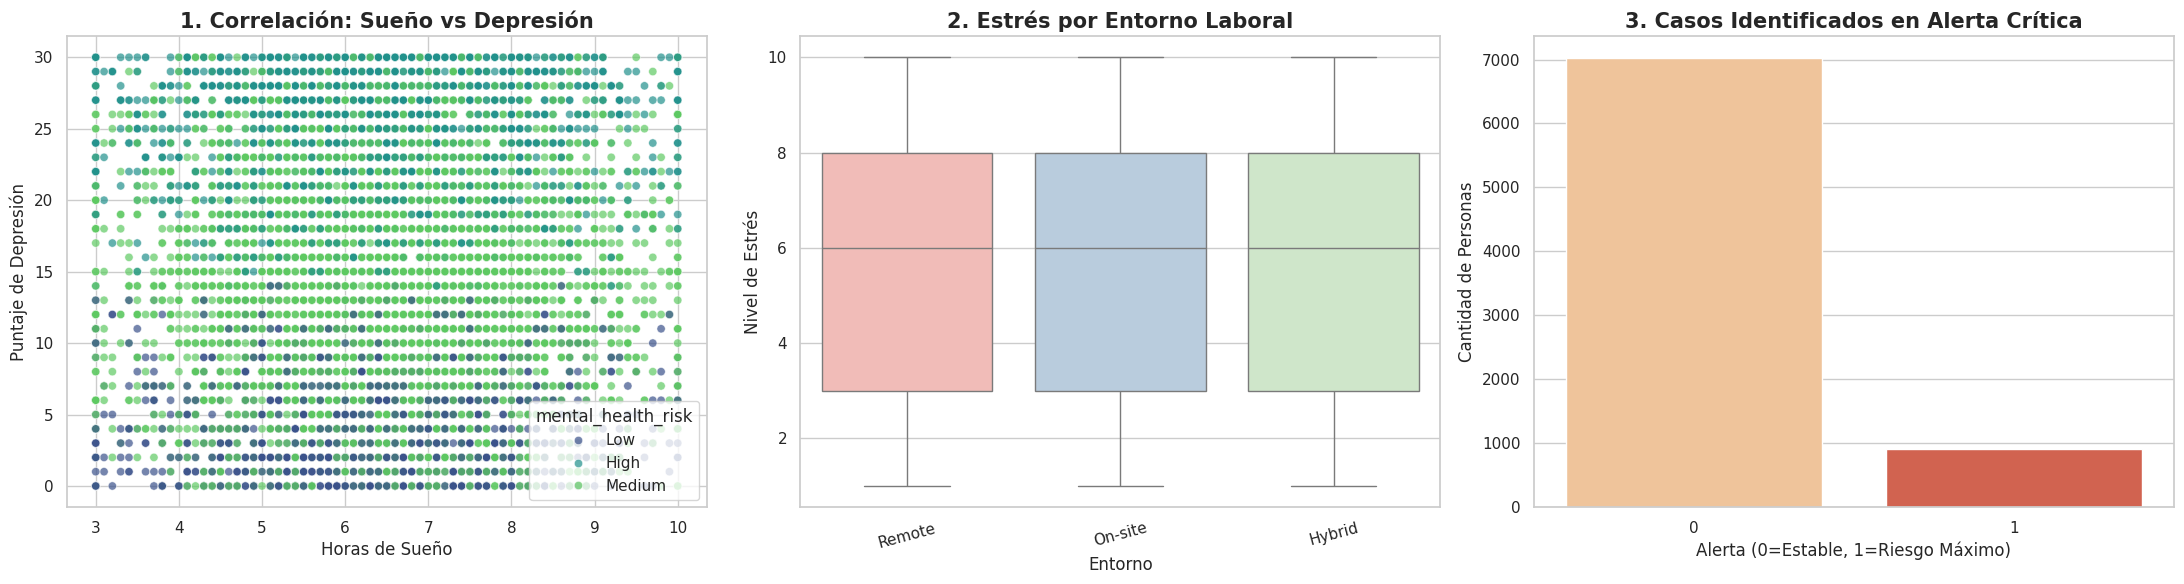

✅ Visualización final generada sin advertencias técnicas.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

print("--- FASE 4: VISUALIZACIÓN FINAL PARA DEFENSA (LÁMINA DE RESULTADOS) ---")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(22, 6))

# 1. Correlación: Sueño vs Depresión
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x='sleep_hours', y='depression_score',
                hue='mental_health_risk', palette='viridis', alpha=0.7)
plt.title('1. Correlación: Sueño vs Depresión', fontsize=15, fontweight='bold')
plt.xlabel('Horas de Sueño')
plt.ylabel('Puntaje de Depresión')

# 2. Boxplot: Estrés por Entorno Laboral (Corregido sin avisos)
plt.subplot(1, 3, 2)
sns.boxplot(data=df_clean, x='work_environment', y='stress_level',
            hue='work_environment', palette='Pastel1', legend=False)
plt.title('2. Estrés por Entorno Laboral', fontsize=15, fontweight='bold')
plt.xticks(rotation=15)
plt.xlabel('Entorno')
plt.ylabel('Nivel de Estrés')

# 3. Countplot: Casos en Alerta Crítica (Corregido sin avisos)
plt.subplot(1, 3, 3)
sns.countplot(data=df_clean, x='mental_health_alert',
              hue='mental_health_alert', palette='OrRd', legend=False)
plt.title('3. Casos Identificados en Alerta Crítica', fontsize=15, fontweight='bold')
plt.xlabel('Alerta (0=Estable, 1=Riesgo Máximo)')
plt.ylabel('Cantidad de Personas')

plt.tight_layout()
plt.show()

print("✅ Visualización final generada sin advertencias técnicas.")